#  Health Camapign Analysis

### Project Goals
- Measure campaign effectiveness, singup rate, understand claim patterns by plan, geography and marketing channels.
  
### North Star Metrics
- **Impressions:** Total number of times a marketing camapign was displayed or viewed by users regardless of whether they interacted with it.
- **Clicks:** Total number of times users clicked  on a campaigns link
- **Click-Through Rate (CTR):** Percentage of impressions  that resulted in a click.It measures how compelling ad creative is at driving action.
- **Cost Per click (CPC):** Average amount of money spent for each click on your campaign
- **Signup Rate:** Percentage of people who completed a signup out of the total number of people who viewed the campaign
- **Cost per signup:** Average amount of money spent to acquire one user signup.
- **Cost per Millie (CPM):** Cost an advertiser pays for 1000 impressions of their ad
- **Claim Count:** The total number of insurance claims filed by customers.

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
%matplotlib inline

In [2]:
file='Health_Data.xlsx'
df_customers=pd.read_excel('../data/'+ file,sheet_name='customers')
df_claims=pd.read_excel('../data/'+file,sheet_name='claims')
df_campaigns=pd.read_excel('../data/'+file,sheet_name='campaigns')

In [3]:
def df_info(df):
    print("Shape:", df.shape)
    print("="*50)
    print("\nNumber of Duplicates:",df.duplicated().sum())
    print("="*50)
    print("\nData Types:\n", df.dtypes)
    print("="*50)
    print("\nNumber of Null Values:\n",(df.isna().sum()).round(2))
    print("="*50)

In [4]:
df_info(df_customers)

Shape: (16338, 8)

Number of Duplicates: 0

Data Types:
 customer_id            object
first_name             object
last_name              object
state                  object
first_touch            object
plan                   object
signup_date    datetime64[ns]
campaign_id            object
dtype: object

Number of Null Values:
 customer_id     0
first_name      0
last_name       0
state           0
first_touch     0
plan            0
signup_date     0
campaign_id    39
dtype: int64


In [5]:
df_info(df_claims)

Shape: (49998, 6)

Number of Duplicates: 0

Data Types:
 customer_id               object
claim_id                   int64
claim_date        datetime64[ns]
claim_category            object
claim_amount             float64
covered_amount           float64
dtype: object

Number of Null Values:
 customer_id       0
claim_id          0
claim_date        0
claim_category    0
claim_amount      0
covered_amount    0
dtype: int64


In [6]:
df_info(df_campaigns)

Shape: (57, 6)

Number of Duplicates: 0

Data Types:
 campaign_id           object
campaign_category     object
campaign_type         object
cost                 float64
impressions            int64
clicks               float64
dtype: object

Number of Null Values:
 campaign_id          0
campaign_category    0
campaign_type        0
cost                 0
impressions          0
clicks               3
dtype: int64


In [7]:
print("Primary Key in Customers",df_customers['customer_id'].nunique())
print("Foreing Key in Claims",df_claims['customer_id'].nunique())

Primary Key in Customers 16338
Foreing Key in Claims 16338


In [8]:
print("Primary Key in Campaigns",df_campaigns['campaign_id'].nunique())
print("Foreing Key in Customers",df_customers['campaign_id'].nunique())

Primary Key in Campaigns 57
Foreing Key in Customers 34


In [9]:
print('Number of Null values of campaign_id in Customer table:',df_customers['campaign_id'].isna().sum())
print('Number of "unknown" values of campaign_id in Customer table:',(df_customers['campaign_id']=='unknown').sum())

Number of Null values of campaign_id in Customer table: 39
Number of "unknown" values of campaign_id in Customer table: 10


In [10]:
marketing_data=df_customers.merge(df_campaigns,on='campaign_id',how='left')
full_data=marketing_data.merge(df_claims,on='customer_id',how='left')

In [11]:
df_info(full_data)

Shape: (49998, 18)

Number of Duplicates: 0

Data Types:
 customer_id                  object
first_name                   object
last_name                    object
state                        object
first_touch                  object
plan                         object
signup_date          datetime64[ns]
campaign_id                  object
campaign_category            object
campaign_type                object
cost                        float64
impressions                 float64
clicks                      float64
claim_id                      int64
claim_date           datetime64[ns]
claim_category               object
claim_amount                float64
covered_amount              float64
dtype: object

Number of Null Values:
 customer_id             0
first_name              0
last_name               0
state                   0
first_touch             0
plan                    0
signup_date             0
campaign_id            92
campaign_category     132
campaign_type        

# 1. Campaign Performance Analysis

In [12]:
def campaign_perf(col,df=df_campaigns):
    df_summary=df.groupby(col).agg({
        'cost':'sum',
        'clicks':'sum',
        'impressions':'sum'
    }).reset_index()
    df_summary['ctr']=(df_summary['clicks']/df_summary['impressions']*100).round(2)
    df_summary['cpc']=(df_summary['cost']/df_summary['clicks'].replace(0,np.nan)).round(2)
    df_summary['cpm']=(df_summary['cost']/df_summary['impressions']*1000).round(2)
    df_summary=df_summary.sort_values(by='ctr',ascending=False)
    grand_total={
    col: 'GRAND TOTAL',
    'cost':df_summary['cost'].sum(),
    'clicks':df_summary['clicks'].sum(),
    'impressions':df_summary['impressions'].sum(),
    'ctr':(df_summary['clicks'].sum()/df_summary['impressions'].sum()*100).round(2),
    'cpc':(df_summary['cost'].sum()/df_summary['clicks'].sum()).round(2),
    'cpm':(df_summary['cost'].sum()/df_summary['impressions'].sum()*1000).round(2)
    }

    table=pd.concat([df_summary,pd.DataFrame([grand_total])],ignore_index=True)
    print(table.to_string(index=False))
    return df_summary

In [13]:
df_category=campaign_perf('campaign_category')

      campaign_category     cost   clicks  impressions   ctr  cpc   cpm
         Health For All  4346.96  43453.0       170559 25.48 0.10 25.49
        Benefit Updates  2151.31  54145.0       244280 22.17 0.04  8.81
   Summer Wellness Tips  7085.68 103667.5       573010 18.09 0.07 12.37
Compare Health Coverage 10043.22  93349.5       664710 14.04 0.11 15.11
       Affordable Plans  1569.15  41593.5       327507 12.70 0.04  4.79
   Preventive Care News  6256.81 136663.0      1116968 12.24 0.05  5.60
       #CoverageMatters  2311.33  74240.0       712100 10.43 0.03  3.25
         #HealthyLiving  6676.64 132067.5      1372448  9.62 0.05  4.86
      #InsureYourHealth  6572.88  74540.0       970244  7.68 0.09  6.77
  Tailored Health Plans  5175.19  92570.0      1398859  6.62 0.06  3.70
  Golden Years Security  4064.70   5979.0       422930  1.41 0.68  9.61
   Family Coverage Plan  3936.42      0.0      1106540  0.00  NaN  3.56
            GRAND TOTAL 60190.29 852268.0      9080155  9.39 0.0

In [14]:
df_type=campaign_perf('campaign_type')

       campaign_type     cost   clicks  impressions   ctr  cpc  cpm
    Health Awareness  4520.52 124169.0       820960 15.12 0.04 5.51
  Policy Information 10814.99 265360.0      1816321 14.61 0.04 5.95
     Covid Awareness 13976.03 125856.5      1514805  8.31 0.11 9.23
Customer Testimonial  8676.86 109730.0      1511676  7.26 0.08 5.74
         Health Tips  5154.66  50398.0       719101  7.01 0.10 7.17
   Product Promotion 10965.81 105050.5      1562824  6.72 0.10 7.02
  Offer Announcement  6081.42  71704.0      1134468  6.32 0.08 5.36
         GRAND TOTAL 60190.29 852268.0      9080155  9.39 0.07 6.63


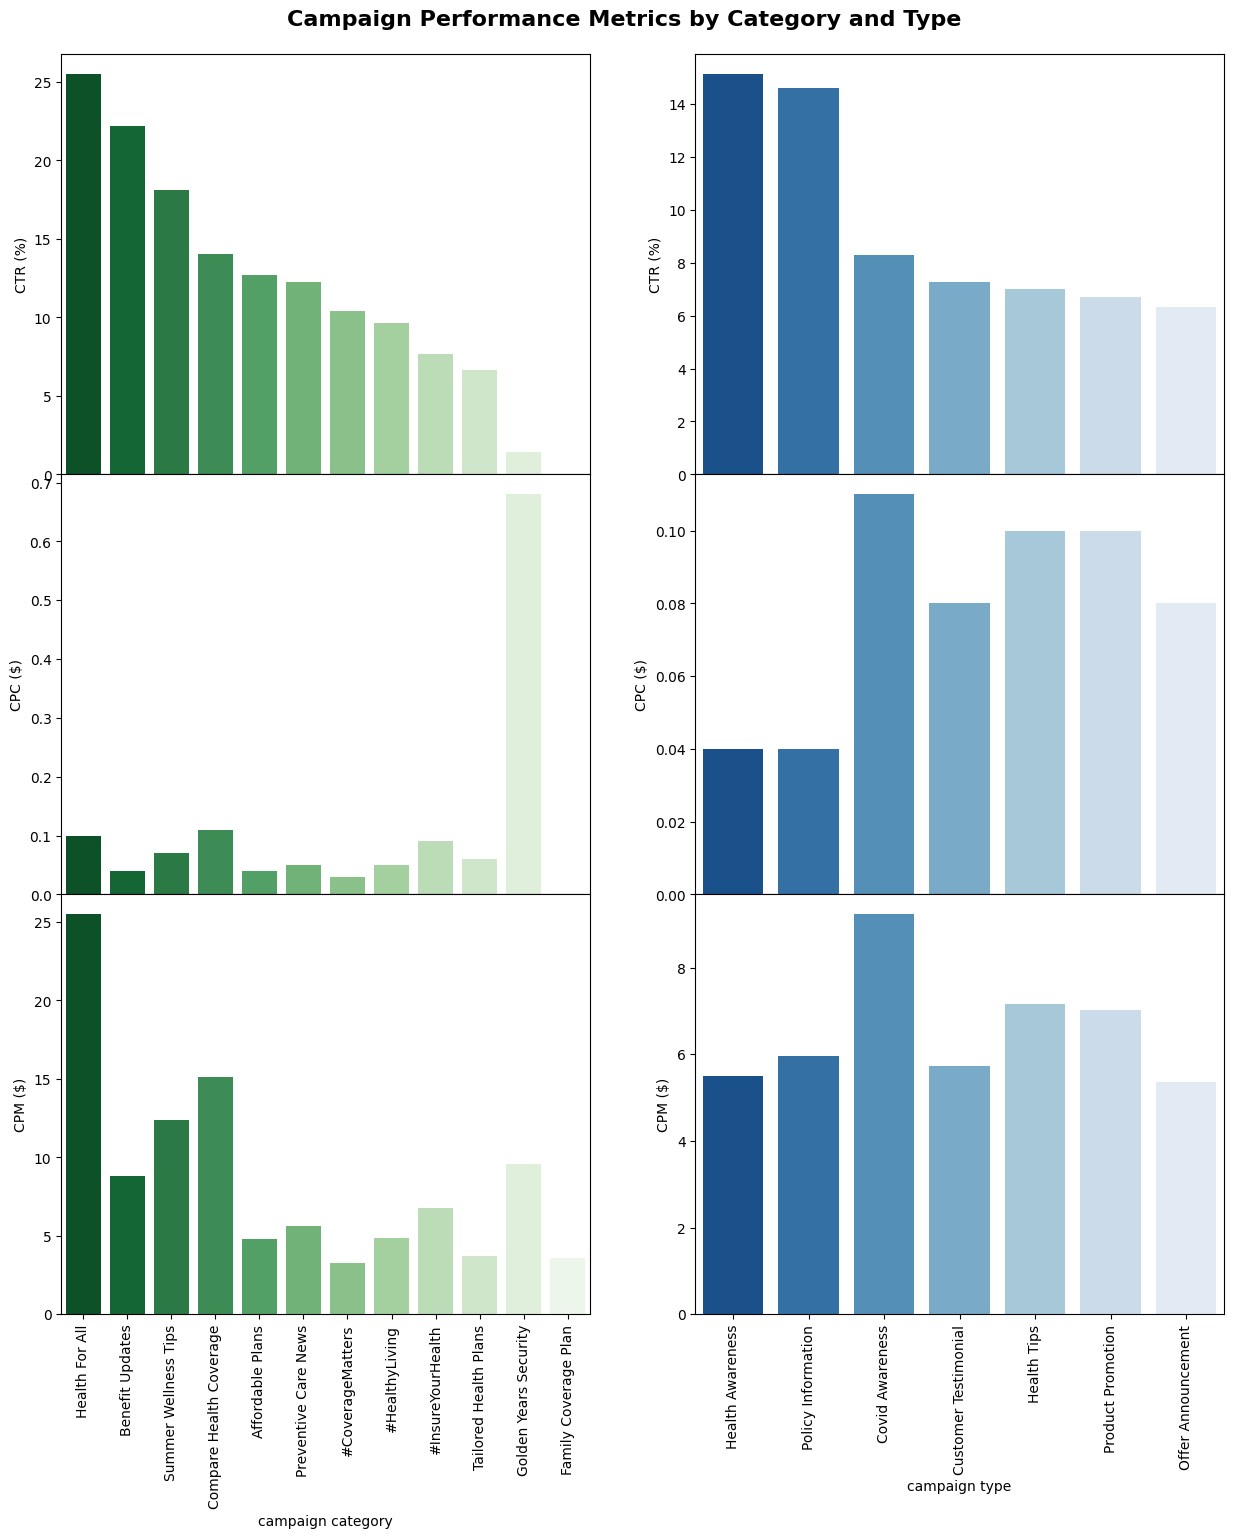

In [15]:
fig,axs=plt.subplots(3,2,figsize=(15,15))
plt.subplots_adjust(hspace=0,top=0.95)
cols=['campaign_category','campaign_type']
rows=['ctr','cpc','cpm']
dfs=[df_category,df_type]
labels=['CTR (%)','CPC ($)', 'CPM ($)']
colors=['Greens_r','Blues_r']

for i,df in enumerate(dfs):
    tickindex=df[cols[i]].tolist()
    for j,yl in enumerate(labels):
        sns.barplot(x=cols[i],y=rows[j],hue=cols[i],data=df,palette=colors[i],ax=axs[j,i])
        axs[j,i].set_ylabel(yl)
        if j==2:
            axs[j,i].set_xticks(tickindex)
            axs[j,i].set_xlabel(cols[i].replace('_', ' '))
            axs[j,i].set_xticklabels(tickindex,rotation=90)
        else:
            axs[j,i].set_xlabel('')
            axs[j,i].set_xticklabels([])

#plt.tight_layout()
fig.suptitle('Campaign Performance Metrics by Category and Type',fontsize=16,fontweight='bold')
plt.show()

# 2. Customer SignUp Analysis

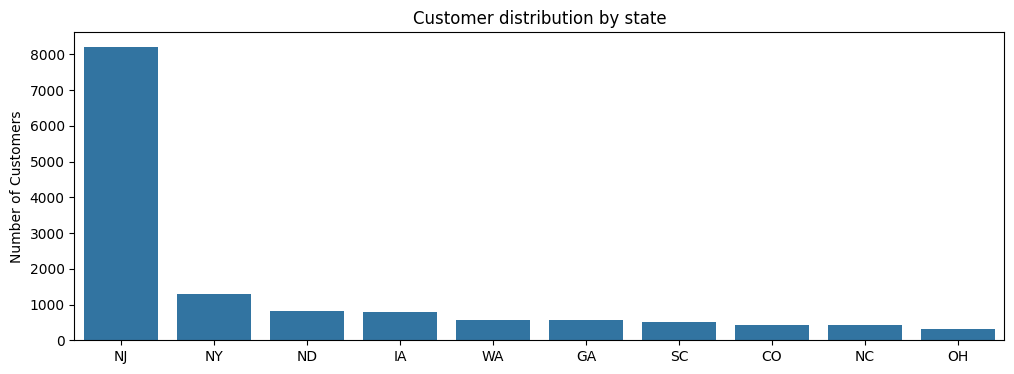

In [16]:
def signup_col(col,df=df_customers):
    signup = df[col].value_counts().reset_index()
    signup.columns = [col, 'customer_count']
    signup = signup.sort_values('customer_count', ascending=False)
    return signup

signup_state=signup_col('state',df_customers)

fig,ax=plt.subplots(1,1,figsize=(12,4))
tickindex=signup_state.head(10).state.tolist()
sns.barplot(y='customer_count',x='state',data=signup_state.head(10),ax=ax)
ax.set_xticks(tickindex)
ax.set_xticklabels(tickindex)
ax.set_ylabel('Number of Customers')
ax.set_xlabel('')
ax.set_title('Customer distribution by state')
plt.show()

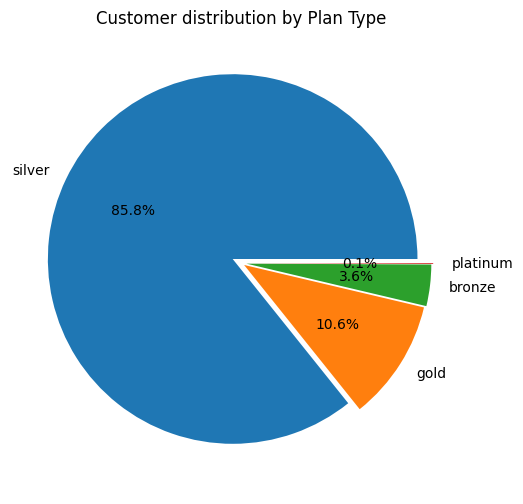

In [17]:
signup_plan=signup_col('plan',df_customers)

fig,ax=plt.subplots(1,1,figsize=(6,6))
tickindex=signup_plan['plan'].tolist()
ax.pie(signup_plan['customer_count'],
      labels=signup_plan['plan'],
      autopct='%1.1f%%',
      explode=[0.05,0.02,0.03,0.04])
ax.set_title('Customer distribution by Plan Type')
plt.show()

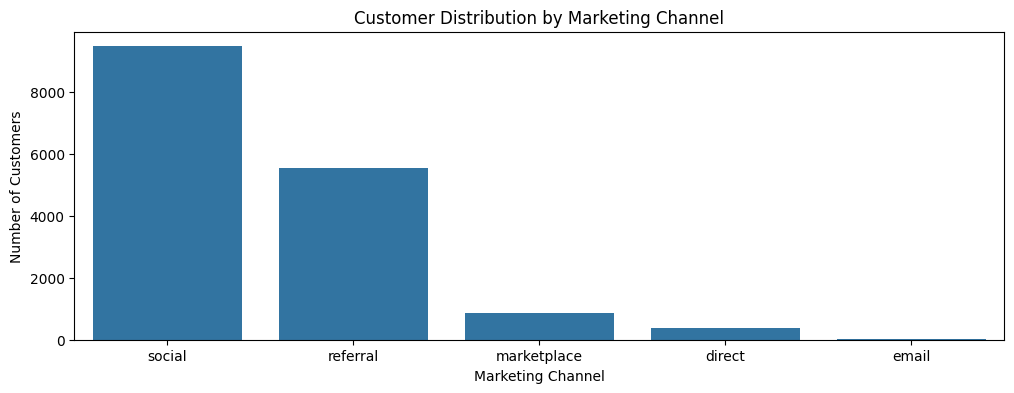

In [18]:
signup_mc=signup_col('first_touch',df_customers)

fig,ax=plt.subplots(1,1,figsize=(12,4))
tickindex=signup_mc['first_touch'].tolist()
sns.barplot(y='customer_count',x='first_touch',data=signup_mc,ax=ax)
ax.set_xticks(tickindex)
ax.set_xticklabels(tickindex)
ax.set_ylabel('Number of Customers')
ax.set_xlabel('Marketing Channel')
ax.set_title('Customer Distribution by Marketing Channel')
plt.show()

In [19]:
signup_camp=df_customers.groupby('campaign_id').agg({
    'customer_id':'nunique'
}).reset_index()
signup_camp.columns=['campaign_id','signup count']
signup_camp=signup_camp.merge(df_campaigns,on='campaign_id',how='left')
signup_category=signup_camp.groupby('campaign_category').agg({
    'signup count':'sum',
    'cost':'sum',
    'impressions':'sum'
}).reset_index()
signup_category['cost per signup']=(signup_category['cost']/signup_category['signup count']).round(2)
signup_category['signup rate']=(signup_category['signup count']/signup_category['impressions']*100).round(2)

signup_category=signup_category.sort_values(by='cost per signup',ascending=False)

In [20]:
grand_total={
    'campaign_category': 'GRAND TOTAL',
    'signup count':signup_category['signup count'].sum(),
    'cost':signup_category['cost'].sum(),
    'cost per signup':(signup_category['cost'].sum()/signup_category['signup count'].sum()).round(2),
    'signup rate':(signup_category['signup count'].sum()/signup_category['impressions'].sum()*100).round(2)
}

pd.concat([signup_category,pd.DataFrame([grand_total])],ignore_index=True)

,campaign_category,signup count,cost,impressions,cost per signup,signup rate
0,Golden Years Security,23,2853.23,348510.0,124.05,0.01
1,Benefit Updates,45,2151.31,244280.0,47.81,0.02
2,Affordable Plans,63,1120.71,306020.0,17.79,0.02
3,Family Coverage Plan,301,3936.42,1106540.0,13.08,0.03
4,#InsureYourHealth,316,3745.39,884930.0,11.85,0.04
5,Summer Wellness Tips,163,1680.63,505720.0,10.31,0.03
6,Preventive Care News,643,3791.76,1025080.0,5.90,0.06
7,Tailored Health Plans,1107,3220.54,1360060.0,2.91,0.08
8,Compare Health Coverage,2820,3976.40,496570.0,1.41,0.57
9,#HealthyLiving,3727,4662.29,1316460.0,1.25,0.28


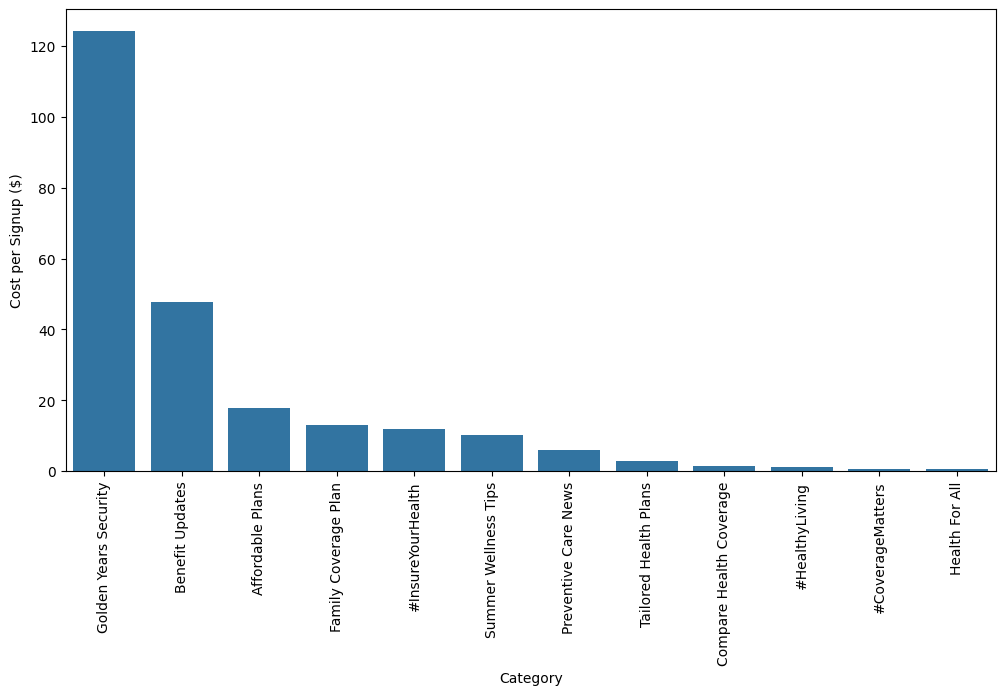

In [21]:
fig,axs=plt.subplots(1,1,figsize=(12,6))
sns.barplot(x='campaign_category',y='cost per signup',data=signup_category,ax=axs)
tickindex=signup_category['campaign_category'].tolist()
axs.set_xticks(tickindex)
axs.set_xticklabels(tickindex,rotation=90)
axs.set_ylabel('Cost per Signup ($)')
axs.set_xlabel('Category')
plt.show()

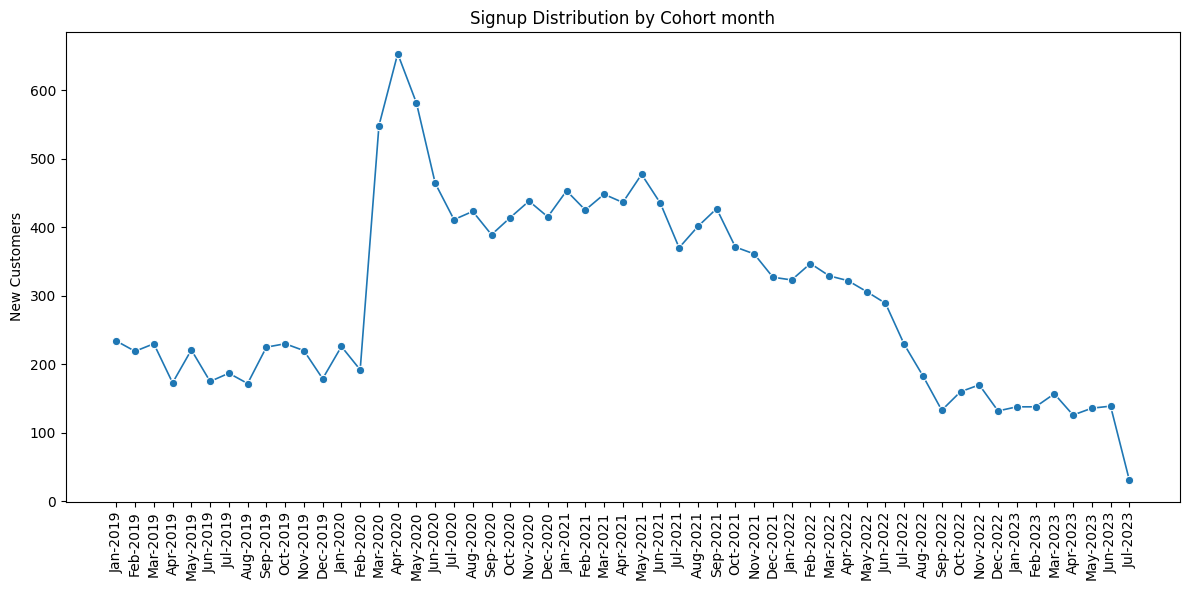

In [22]:
df_customers['cohort_month_str']=df_customers['signup_date'].dt.strftime('%b-%Y')
df_customers['cohort_month']=df_customers['signup_date'].dt.to_period('M')
signup_cohort = df_customers['cohort_month'].value_counts().reset_index()
signup_cohort.columns = ['cohort_month', 'customer_count']
signup_cohort = signup_cohort.sort_values('cohort_month')
signup_cohort['cohort_month_str']=signup_cohort['cohort_month'].dt.strftime('%b-%Y')

fig,ax=plt.subplots(1,1,figsize=(12,6))
sns.lineplot(data=signup_cohort,x='cohort_month_str',y='customer_count',ax=ax,
            marker='o',lw=1.2)
ax.set_xticks(signup_cohort['cohort_month_str'])
ax.set_xticklabels(signup_cohort['cohort_month_str'], rotation=90)
ax.set_ylabel('New Customers')
ax.set_xlabel('')
ax.set_title('Signup Distribution by Cohort month')
plt.tight_layout()
plt.show()

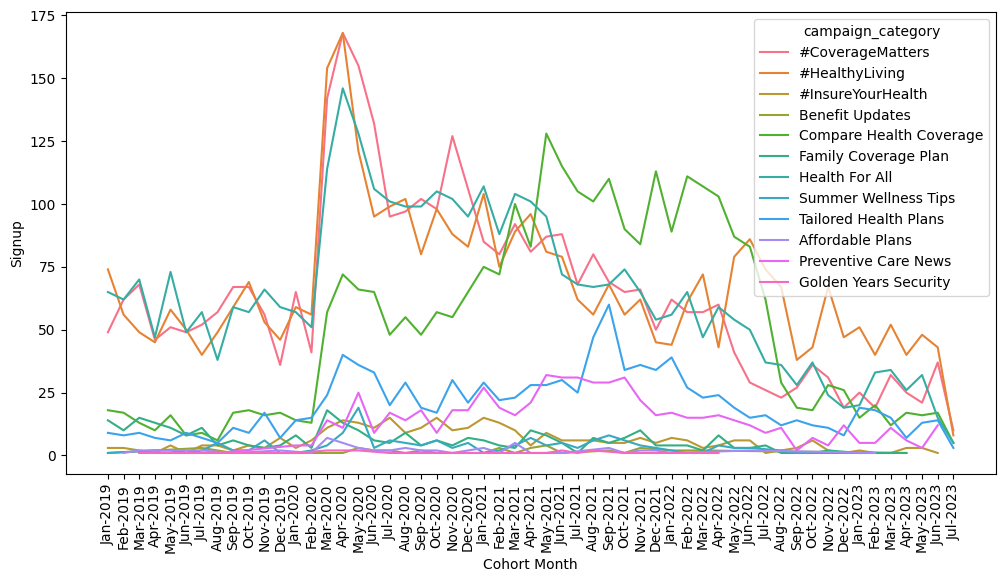

In [23]:
#campaign_category_map = df_campaigns.set_index('campaign_id')['campaign_category'].to_dict()
#df_customers['campaign_category'] = df_customers['campaign_id'].map(campaign_category_map)
#df_customers['campaign_category'] = df_customers['campaign_category'].fillna('Unknown')

df_customers_campaigns=df_customers.merge(df_campaigns,on='campaign_id',how='left')
signup_campaign=df_customers_campaigns.groupby(['cohort_month','campaign_category']).size().reset_index(name='signup')
signup_campaign=signup_campaign.sort_values(by='cohort_month')
signup_campaign['cohort_month_str']=signup_campaign['cohort_month'].dt.strftime('%b-%Y')
fig,ax=plt.subplots(1,1,figsize=(12,6))
sns.lineplot(x='cohort_month_str',y='signup',hue='campaign_category',data=signup_campaign,ax=ax)
ax.set_xlabel('Cohort Month')
ax.set_ylabel('Signup')
plt.xticks(rotation=90)
plt.show()

# Claim Analysis

In [24]:
claim_perf=full_data.groupby(['campaign_category']).agg({
    'claim_amount':'sum',
    'claim_id':'nunique'
}).rename(columns={'claim_id':'claim count'}).reset_index()
claim_perf=claim_perf.sort_values(by='claim_amount',ascending=False)

claim_perf['Avg Claim Amount']=(claim_perf['claim_amount']/claim_perf['claim count']).round(0)

grand_total={'campaign_category':'GRAND TOTAL','claim_amount':claim_perf['claim_amount'].sum(),
             'claim count':claim_perf['claim count'].sum(),
             'Avg Claim Amount':(claim_perf['claim_amount'].sum()/claim_perf['claim count'].sum()).round(0)}
pd.concat([claim_perf,pd.DataFrame([grand_total])],ignore_index=True)

,campaign_category,claim_amount,claim count,Avg Claim Amount
0,Compare Health Coverage,3.902045e+06,9507,410.0
1,Health For All,2.824383e+06,12232,231.0
2,#HealthyLiving,2.615390e+06,10707,244.0
3,#CoverageMatters,2.507444e+06,11016,228.0
4,Tailored Health Plans,4.898737e+05,2347,209.0
5,Family Coverage Plan,3.225982e+05,1266,255.0
6,Preventive Care News,3.106405e+05,1145,271.0
7,#InsureYourHealth,1.537885e+05,702,219.0
8,Summer Wellness Tips,1.246208e+05,572,218.0
9,Affordable Plans,4.130836e+04,174,237.0


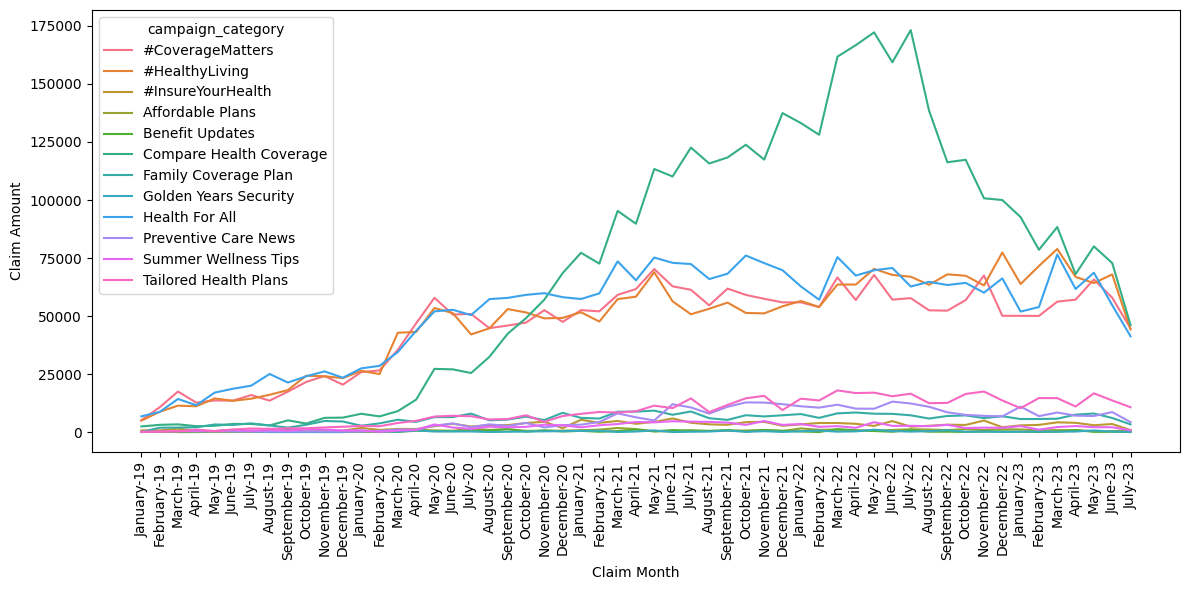

In [25]:
full_data_plot=full_data.sort_values(by='claim_date')
full_data_plot['claim_month']=full_data_plot['claim_date'].dt.to_period('M')
claim_plot=full_data_plot.groupby(['campaign_category','claim_month']).agg({'claim_amount':'sum'}).reset_index()
claim_plot['claim_month_str']=claim_plot['claim_month'].dt.strftime('%B-%y')
fig,ax=plt.subplots(1,1,figsize=(12,6))
sns.lineplot(x='claim_month_str',y='claim_amount',hue='campaign_category',data=claim_plot,ax=ax)
ax.set_xlabel('Claim Month')
ax.set_ylabel('Claim Amount')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Customer Level Analysis

In [26]:
customer_claim = df_claims.groupby('customer_id').agg({
    'claim_amount': 'sum',
    'covered_amount': 'sum',
    'claim_id': 'count'
}).rename(columns={'claim_id': 'claim_count'}).reset_index()

customer_claim = customer_claim.merge(df_customers[['customer_id', 'campaign_id', 'first_touch', 'plan']], on='customer_id')
customer_claim['avg_claim_value'] = (customer_claim['claim_amount'] / customer_claim['claim_count']).round(2)
customer_claim['coverage_rate']=(customer_claim['covered_amount']/customer_claim['claim_amount']*100).round(2)


customer_claim.head(10)

,customer_id,claim_amount,covered_amount,claim_count,campaign_id,first_touch,plan,avg_claim_value,coverage_rate
0,c1,107.100,74.970,1,CAM030,social,gold,107.10,70.00
1,c10,630.000,441.000,5,CAM030,social,gold,126.00,70.00
2,c100,123.180,73.908,1,CAM018,social,silver,123.18,60.00
3,c1000,332.445,199.467,2,CAM031,social,silver,166.22,60.00
4,c10000,113.600,68.160,1,unknown,referral,silver,113.60,60.00
5,c10001,1838.150,1152.036,7,CAM030,social,silver,262.59,62.67
6,c10002,1593.720,1056.888,10,CAM004,marketplace,gold,159.37,66.32
7,c10003,347.155,208.293,3,CAM018,social,silver,115.72,60.00
8,c10004,360.000,216.000,1,CAM018,referral,silver,360.00,60.00
9,c10005,126.000,75.600,1,CAM018,social,silver,126.00,60.00


In [27]:
customer_by_plan = customer_claim.groupby('plan').agg({
    'customer_id': 'count',
    'claim_amount': 'mean',
    'claim_count': 'mean',
    'coverage_rate':'mean'
}).round(2)
customer_by_plan.columns = ['Total Customer','Avg Claim Amount', 'Avg Claims per Customer', 'Avg Coverage Rate']
customer_by_plan

,Total Customer,Avg Claim Amount,Avg Claims per Customer,Avg Coverage Rate
plan,,,,
bronze,591,434.71,1.63,50.06
gold,1725,1000.98,3.37,70.18
platinum,12,818.21,3.25,80.00
silver,14010,811.25,3.08,60.22


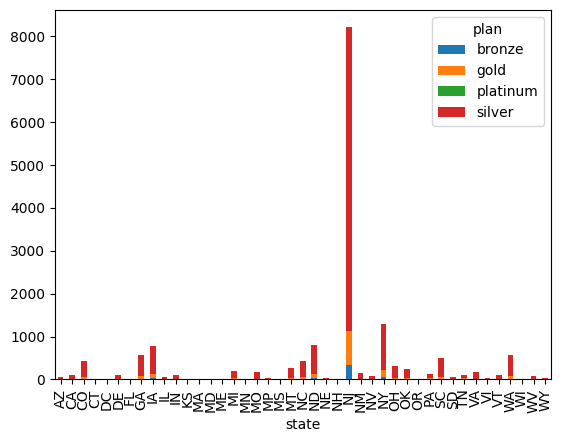

In [28]:
#sns.countplot(data=df_customers,x='plan')
state_plan=df_customers.groupby(['state','plan']).size().unstack().fillna(0)
state_plan.plot(kind='bar',stacked=True)
plt.show()

<Axes: xlabel='plan', ylabel='claim_amount'>

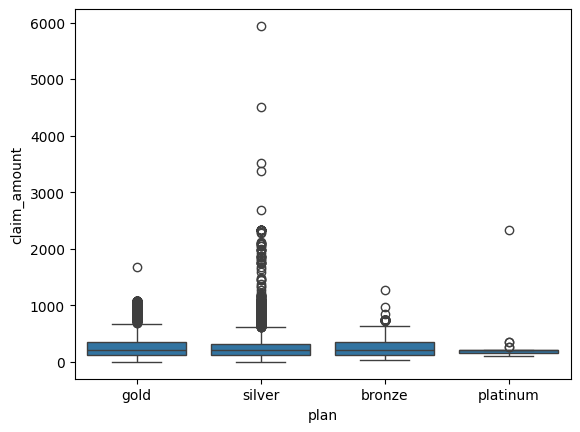

In [29]:
sns.boxplot(data=full_data,x='plan',y='claim_amount')

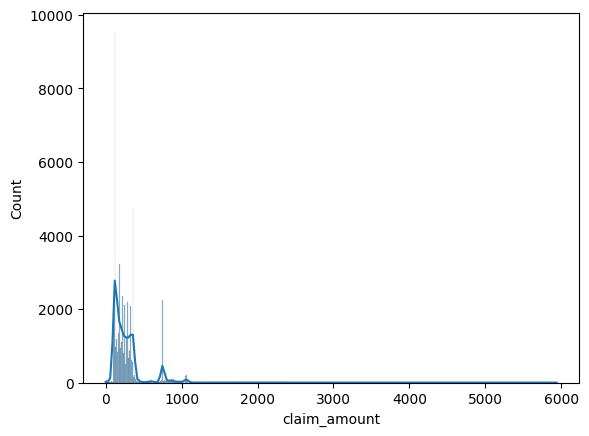

In [30]:
sns.histplot(data=full_data,x='claim_amount',kde=True)
plt.show()

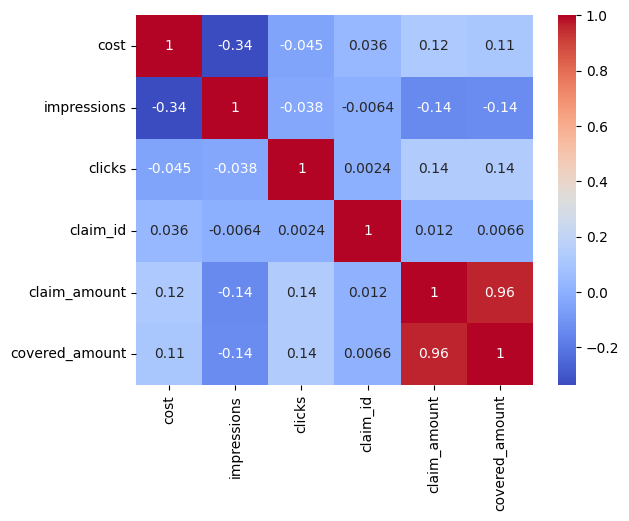

In [33]:
sns.heatmap(full_data.corr(numeric_only=True),cmap='coolwarm',annot=True)
plt.show()

# Health Marketing Analysis

[![Python](https://img.shields.io/badge/Python-3.8+-blue?logo=python&logoColor=white)](https://www.python.org)
[![Tableau Public](https://img.shields.io/badge/Tableau%20Public-E97627?logo=tableau&logoColor=white)](https://public.tableau.com)
[![Power BI](https://img.shields.io/badge/Power%20BI-F2C811?logo=powerbi&logoColor=black)](https://powerbi.microsoft.com)
[![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://opensource.org/licenses/MIT)



This project analyzes marketing performance for a US based medical insurance company founded in 2015. The company offers four plans **Bronze, Silver, Gold, and Platinum** with different premiums and levels of coverage. In 2019, the company introduced new marketing campaign categories aimed at increasing customer acquisition, improving brand awareness across US, and drive enrollment in higher value plans.

The goal of the analysis is to evaluate the effectiveness of these marketing strategies in terms of customer signups and subsequent insurance claims. The insights generated will support data driven budget allocation decisions for future marketing campaigns.


<details>
<summary> <b>Key Stakeholder Questions</b></summary>
The health insurance company wants to understands how the marketing campaigns are performing and increase low risk signups in premium plans.
    
- Which marketing camapings generate the highest number of signups?
- How should the marketing budget be allocated to maximize impact?
- How do different campaigns influence plan selection?

</details>
<details>
<summary> <b>Data & Tech Info</b> </summary>

- **Data Processing & Analysis**: Python, Pandas, NumPy, Excel, SQL
- **Visualization**: Matplotlib, Seaborn, Plotly
- **Dashboard**: Tableau (explored with Power BI desktop as well)

</details>

[**View Tableau Dashboard**](link here)



**Overall Performance** across all campaigns:

| North Star Metrics | Value |
|--|--|
| **Click Through Rate (CTR)** | **9.39%** |
| **Cost per Click (CPC)** | **\$0.07** |
| **Total Signups** | **16,289** |
| **Signup Rate** | **0.18%** |
| **Cost per Signup** | **\$3.68** |
| **Average Claim Amount** | **\$267** |


## 1. Campaign Performance Insights


>
> <table width="100%">
>   <tr>
>     <td align="center" width="50%">
>       <img src="../images/Marketingmetrics.png" width="100%"><br>
>     </td>
>     <td align="center" width="50%">
>       <img src="../images/MarketingScatter.png" width="100%"><br>
>     </td>
>   </tr>
>   <tr>
>     <td colspan="2">
>       <b>Fig. 1a.</b> Marketing Campaign efficiency metrics(click per cost (CPC), Click per Signup, and Click Through Rate (CTR)) by campaign category. <b>1b.</b> Average Claim per Customer vs Cost per Signup by Campaign Category where bubble size shows Avg. claim amount and color shows campaign category.
></td></tr>
> </table>
>


- **Health for All** and **Benefit Updates** campaigns have the strongest customer engagement with the highest click through rate (CTR) (~25% and ~22%). High CTR indicates compelling messaging and effective tarteting that resonates well with the audience.
- **Healthy Living** campaigns  with 0.10 CTR drive the largest share of total signups (~23%) followed closely by **Health for All** and **Coverage Matters** campaigns (each ~22%). This suggests that CTR reflects initital engagement, conversion success also depends heavily on audience targeting and camapign relevance.
- Overall campaign performance remains efficient with an average **CPC of \$0.07**, and **Cost per Signup of \$3.68**. 
- **Golden Years Security** campaigns stand out as extreme outliers with the **highest CPC(\$0.68)** and **Cost per Signup (\$177)**. The scatter plot (Fig. 1b) position this category in the **high cost and high claim** quadrant suggesting inefficient acquisition and high downstream claims risk. The marketing budget allocation for this campaign should be kept under priority for review.
- **Compare Health Coverage** generated the highest average claim amount despite realtively low acquisition costs. While cost efficient on the front end, this campaign requires further analysis to determine whether savings on acquisitions will be outperformed by higher long term claims exposure.
- **Covid awareness** type of campaigns has low signup contribution with high cost per click \$0.11. 
- **Tailored Health Plans** campaign has the lowest average claim per customer while maintaining a Cost per signup of only **\$5** (Fig. 1b). This combination of cost efficiency and favorable risk profile makes them a strong camapign category for increased investments.
- **Offer Announcements** based campaigns generated minimal engagement, with lowest click through rate (CTR) of ~6% among the campaign types resulting in only 61 signups.
- **Health Awareness** and **Policy information** based Campaigns delivered solid engagement with high click through rate of 15% and low click per cost **\$0.04**. 
- There are Critical quality signals with several anomalies. 
	-**Family Coverage Plan** campaigns recorderd **~1.1M impressions with zero clicks** which is highly unlikely in a real world scenario. 
	- **Policy Information** based campaigns under the **Health for All category** incurred \$1,254 spend with zero signups. 
	- **Golden Years Security** showed instances of zero clicks despsite meaningful spend for the Covid awarenesss based camapaigns.
These zero activity or extreme outliers will affect decision making.


 **Recommendations**
 - **Scale High Performing, Low Risk Campaigns**\
 Prortized increased investment in\
            - **Health for All** (high engagment and high conversion)\
     		- **Healthy Living** (highest signup volume)\
     		- **Tailored Health Plans** (cost efficient and low claims risk)\
 - **Review or  Discontinue High Cost or High Risk Campaigns** 
	- Reassess **Golden Years Security** camapaigns due to poor risk and high risk profile. Conisder pausing or shifting budget away from underperforming campaing types like COVID awareness, product promotions.
	- **Compare Health Coverage** may be attracting higher risk customer profiles. Further full claims vs acquisition analysis required before any scaling to enure long term profitability.
- **Reduce or Pause Low Impact Campaigns**
 	- Scale back **Offer Announcements and COVID Awareness** based campaigns which have limited engagement and conversiton imapct.
 - **Immediate Data Quality Analysis**\
    Investigate anomalies (zero clicks on high impressions, spend without conversions) to validate tracking integrity. Implement closed loop reporting that connects marketing data with enrollment and claims system for more reliable insights.


## 2. Claim Analytics Insights

Overall Claims Behavior:
- **Total Claims Filed**:~50K
- **Average Claims per Customer**:3.1
- **Average Claim Amount**: \$267

>
> <table width="100%">
>   <tr>
>     <td align="center" width="50%">
>       <img src="../images/ClaimTrend.png" width="100%"><br>
>     </td>
>     <td align="center" width="50%">
>       <img src="../images/PlanTreemap.png" width="100%"><br>
>     </td>
>   </tr>
>   <tr>
>     <td colspan="2">
>       <b>Fig. 2a.</b> Monthly Claims Trend by Campaign Category. <b>2b.</b> Plan Performance Overview: Customers, Claims & Coverage Rate. (Inset: Claim amount distribution boxplot for Silver Plan).
></td></tr>
> </table>
>

- Average coverage rate across plans are Platinum (80\%), Gold (70\%), Silver (60\%), and Bronze (50\%).
- Customers are filing an average of 3.1 claims each signaling strong utilization and engagement with the insurance plans. However, this highlights the importance of acquiring low risk customers to sustain long term profitability.
-  **Compare Health Coverage** campaigns generates the highest and fastest growing claim volumes.  Fig. 2a shows that monthly claims from this category peaked at \$173K in July 2022 and show an average claim rate approximately 50\% higher than the average claim rate. In contrast, **Health for All, Healthy Living, and Coverage Matters** campaigns experienced claim increases from 2019 but have since stabilized around \$50K per month. This more predictable and stable claims behvior makes them far more reliable for scaling.
- **Compare Health Coverage** campaigns appear to be attracting higher cost customer profile. 
- The Silver plan is the primary revenue driver with highest customer volume but also the highest risk segment with the largest  claim amount. The claim amount distribution revelas presence of outliers with extremely high claim values suggesting that higher risk customers are choosing mid tier plans.

**Recommendations**
- **Reduce over reliance on Silver Plan Acquisitons**\
	 Shift focus toward targeted upsell campaigns to migrate existing Silver customers to Gold and Platinum plans, improving the overall risk mix and increasing average coverage rates.
- R**efine High Risk Campaign Targeting**\
	Reassess **Compare Health Coverage** campaigns by tightening audience segmentation to exclude high risk profiles. 
- **Investigate Claim Outliers**\
	Conduct a detailed analysis of extreme high claim cases in the silver plan to identify patterns and root causes. This will help to setup exclusion criteria in future marketing.
- **Boost Platinum Plan Adoption**\
	 Platinum currently has critically low uptake (only 12 customers). Revisit pricing, positioning, and benefit bundles. Offer incentives to increase uptake.
- **Use Predictive Analytics for Dynamic Targeting**\
	Use historical claims data to build models that predict high risk customers at the point of signup. Integrate these insights into campaign targeting to dynamically favor lower risk segments and optimize the acquisition efficiency.

## 2. Claim Analytics Insights

>
> <table width="100%">
>   <tr>
>     <td align="center" width="50%">
>       <img src="../images/ClaimTrend.png" width="100%"><br>
>     </td>
>     <td align="center" width="50%">
>       <img src="../images/PlanTreemap.png" width="100%"><br>
>     </td>
>   </tr>
>   <tr>
>     <td colspan="2">
>       <b>Fig. 2a.</b> Monthly Campaign Trend by campaign category. <b>2b.</b> Plan Performance Overview: Customers, Claims & Coverage Rate
></td></tr>
> </table>
>


## 3. Customer Insights


>
> <table width="100%">
>   <tr>
>     <td align="center" width="50%">
>       <img src="../images/Customer.png" width="100%"><br>
>     </td>
>     <td align="center" width="50%">
>       <img src="../images/Sankey.png" width="100%"><br>
>     </td>
>   </tr>
>   <tr>
>     <td colspan="2">
>       <b>Fig. 3a.</b> [Top Row] Signups by Marketing channel. [Bottom Row] Total Claims & Claim Amount by State & Plan <b>3b.</b> Customer Journey flow from First Touch (Marketing Channel) to Campaign Category to Plan.
></td></tr>
> </table>
>